# Mason's Airbrake Controller — Flight Simulation

Simulates 1-D vertical flight of the Goanna rocket using:
- **Thrust / mass curves** interpolated from `Goanna_new.csv` (OpenRocket export)
- **Cd model**: firmware 9-term degree-2 polynomial (R²=0.858 on CFD data)
- **Atmosphere**: ISA model (exact port from `Atmosphere.cpp`)
- **Controller**: direct Python port of `AirbrakeController.cpp` (GOANNA_PIL config)

**Note on Cd model vs deployed code:** The `.cpp` code found in the repo (`AirbrakeController`) uses a
simpler 3-term linear Cd model. The 9-term degree-2 polynomial used here was attributed to
`ClosedLoopController.cpp` in the project's history and analysed in `airbrake_cd_comparison.ipynb`.
Both models are shown where relevant.

**Scenarios compared:**
1. No airbrakes (baseline — brakes fully closed throughout coast)
2. Controller active (GOANNA_PIL gain = −0.035, target apogee = 2500 m)

## §1 — Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [2]:
# ── Load Goanna OpenRocket simulation ────────────────────────────────────────
CSV_PATH = "../Mason's Sims/Rocket_Controller/Rocket_Controller/Goanna_new.csv"

# Header is the last #-comment line
with open(CSV_PATH) as f:
    raw = f.readlines()

header_line = next(l for l in reversed(raw) if l.startswith('#') and 'Time' in l)
cols = [c.strip() for c in header_line.lstrip('# ').split(',')]
data_lines = [l for l in raw if not l.startswith('#')]

or_df = pd.read_csv(pd.io.common.StringIO(''.join(data_lines)), names=cols)

t_or  = or_df['Time (s)'].values
h_or  = or_df['Altitude (m)'].values
v_or  = or_df['Vertical velocity (m/s)'].values
T_or  = or_df['Thrust (N)'].values
m_or  = or_df['Mass (kg)'].values

print(f"OpenRocket: {len(or_df)} time steps, dt ≈ {np.diff(t_or).mean()*1000:.1f} ms")
print(f"  Motor burnout: t={t_or[np.where(T_or > 10)[0][-1]]:.2f}s, "
      f"alt={h_or[np.where(T_or > 10)[0][-1]]:.0f}m, "
      f"v={v_or[np.where(T_or > 10)[0][-1]]:.1f}m/s")
print(f"  Mass at burnout: {m_or[np.where(T_or > 10)[0][-1]]:.2f} kg")
print(f"  OpenRocket apogee (no brakes): {h_or.max():.1f} m at t={t_or[h_or.argmax()]:.1f}s")

OpenRocket: 904 time steps, dt ≈ 199.2 ms
  Motor burnout: t=3.35s, alt=654m, v=292.2m/s
  Mass at burnout: 13.06 kg
  OpenRocket apogee (no brakes): 2844.7 m at t=22.6s


In [3]:
# ── Build interpolators for thrust and mass ──────────────────────────────────
thrust_interp = interp1d(t_or, T_or, bounds_error=False, fill_value=0.0)
mass_interp   = interp1d(t_or, m_or, bounds_error=False,
                         fill_value=(m_or[0], m_or[-1]))

# Burnout time = last timestep with thrust > 10 N
burnout_idx = np.where(T_or > 10)[0][-1]
t_burnout   = t_or[burnout_idx]
print(f"Burnout time: {t_burnout:.2f} s")

Burnout time: 3.35 s


## §2 — Physics Models

In [4]:
# ── Constants ────────────────────────────────────────────────────────────────
G     = 9.80665   # m/s²

# ── ISA atmosphere (direct port of Atmosphere.cpp) ───────────────────────────
# T = T0 + lambda*h,   rho = rho0 * (T/T0)^(exp-1)
# exp = -g*M / (R*lambda)
_T0    = 288.15      # K
_lam   = -6.5e-3     # K/m
_rho0  = 1.225       # kg/m³
_exp   = (-G * 28.97e-3) / (8.314472 * _lam)   # ≈ 5.256

def air_density(h):
    """ISA air density at altitude h (m) — matches Atmosphere.cpp exactly."""
    T = _T0 + _lam * h
    return _rho0 * (T / _T0) ** (_exp - 1)

# ── Firmware Cd polynomial (9-term degree-2) ─────────────────────────────────
# Basis: [1, A, rho, v, A², A·rho, A·v, rho², v²]
# Source: ClosedLoopController.cpp (R²=0.858 on CFD_final.csv, 700 pts)
_C = np.array([1.2713593, -89.295723, -0.13991502, -0.0006423065,
                2402.8217,   5.0624507,  0.011055673,  0.0020892442,
                6.7298901e-07])

def cd_firmware(A, rho, v):
    """9-term degree-2 Cd polynomial (firmware poly)."""
    return (_C[0] + _C[1]*A + _C[2]*rho + _C[3]*v
            + _C[4]*A**2 + _C[5]*A*rho + _C[6]*A*v
            + _C[7]*rho**2 + _C[8]*v**2)

# Quick sanity check at a mid-flight condition
_A_min = 0.018801  # m² — brakes fully closed
_A_max = 0.024153  # m² — brakes fully open
_rho_mid, _v_mid = air_density(1200), 150.0
print(f"Cd at mid-flight (A_min, rho={_rho_mid:.3f}, v={_v_mid}m/s): "
      f"{cd_firmware(_A_min, _rho_mid, _v_mid):.4f}")
print(f"Cd at mid-flight (A_max, rho={_rho_mid:.3f}, v={_v_mid}m/s): "
      f"{cd_firmware(_A_max, _rho_mid, _v_mid):.4f}")

Cd at mid-flight (A_min, rho=1.090, v=150.0m/s): 0.3456
Cd at mid-flight (A_max, rho=1.090, v=150.0m/s): 0.4584


## §3 — Controller (Python port of `AirbrakeController.cpp`)

Parameters from `AirbrakeControllerProfiles.hpp` → `GOANNA_PIL` config.  
Physical area limits taken from CFD data rather than PIL test config.

In [5]:
# ── GOANNA_PIL controller parameters ─────────────────────────────────────────
TARGET_APOGEE = 2500.0    # m
ROCKET_MASS   = 13.00     # kg (post-burnout)
A_MIN         = 0.018801  # m² — brakes closed
A_MAX         = 0.024153  # m² — brakes fully open (from CFD envelope)
K_CTRL        = -0.035    # m²/(m/s) — velocity-error → area gain


def controller_step(h, v, A_prev):
    """
    One controller tick. Returns (A_cmd, v_target, apogee_est).

    Faithful port of AirbrakeController::update() from AirbrakeController.cpp:
      1. Compute Cd at current state
      2. Compute terminal velocity (using A_MIN per firmware)
      3. Compute target velocity trajectory (NASA drag-coast eqn)
      4. Velocity error → area command (proportional, unclamped in firmware)
      5. Compute estimated apogee (NASA drag-coast eqn)
    """
    rho = air_density(h)
    Cd  = cd_firmware(A_prev, rho, abs(v))

    # Terminal velocity — firmware uses A_MIN for Vt (per Rocket_Controller 3 code)
    Vt2 = (2.0 * ROCKET_MASS * G) / max(Cd * rho * A_MIN, 1e-9)
    Vt  = np.sqrt(max(Vt2, 0.0))

    # Estimated apogee from current state
    # Source: NASA Flight Equations with Drag
    v2  = v * v
    if Vt2 > 0:
        apogee_est = h + (Vt2 / (2.0 * G)) * np.log((v2 + Vt2) / Vt2)
    else:
        apogee_est = h

    # Target velocity trajectory
    if h >= TARGET_APOGEE:
        v_target = 0.0
    else:
        alt_err = TARGET_APOGEE - h
        w = alt_err / (Vt2 / (2.0 * G))
        inner = Vt2 * np.exp(w) - Vt2
        v_target = np.sqrt(max(inner, 0.0))

    # Control effort: velocity error → area delta
    v_error  = v_target - v
    A_delta  = K_CTRL * v_error          # gain < 0: too fast → positive area
    A_cmd    = A_MIN + A_delta
    A_cmd    = np.clip(A_cmd, A_MIN, A_MAX)

    return A_cmd, v_target, apogee_est


print("Controller loaded. Parameters:")
print(f"  Target apogee: {TARGET_APOGEE} m")
print(f"  Mass:          {ROCKET_MASS} kg")
print(f"  A_min/A_max:   {A_MIN:.6f} / {A_MAX:.6f} m²")
print(f"  K_ctrl:        {K_CTRL}")

Controller loaded. Parameters:
  Target apogee: 2500.0 m
  Mass:          13.0 kg
  A_min/A_max:   0.018801 / 0.024153 m²
  K_ctrl:        -0.035


## §4 — Simulation Loop

RK4 integrator, dt = 0.01 s.  
State = [altitude h, vertical velocity v].  
EOM:  `dh/dt = v`,  `dv/dt = (T − F_drag) / m − g`

Drag uses `v|v|` so it always opposes motion (handles descent correctly).  
Controller activates at motor burnout.

In [6]:
DT     = 0.01    # s
T_END  = 60.0    # s — well past apogee


def simulate(control_active=True):
    """
    Run 1-D vertical flight simulation.

    Returns dict of time-series arrays:
      t, h, v, A, v_target, apogee_est, F_drag, Cd_val
    """
    times        = []
    altitudes    = []
    velocities   = []
    areas        = []
    v_targets    = []
    apogee_ests  = []
    drag_forces  = []
    cd_vals      = []

    # Initial conditions (on pad)
    t = 0.0
    h = 0.0
    v = 0.0
    A = A_MIN          # brakes closed until controller takes over
    apogee_est = 0.0
    v_target   = 0.0

    def derivatives(t, h, v, A):
        rho    = air_density(max(h, 0.0))
        Cd     = cd_firmware(A, rho, abs(v))
        F_drag = 0.5 * rho * Cd * A * v * abs(v)   # sign follows velocity
        mass   = mass_interp(t)
        thrust = thrust_interp(t)
        dv_dt  = (thrust - F_drag) / mass - G
        return v, dv_dt, rho, Cd, F_drag

    while t <= T_END:
        # Record
        rho, Cd, F_drag = air_density(max(h, 0.0)), 0.0, 0.0
        Cd = cd_firmware(A, rho, abs(v))
        F_drag = 0.5 * rho * Cd * A * v * abs(v)

        times.append(t)
        altitudes.append(h)
        velocities.append(v)
        areas.append(A)
        v_targets.append(v_target)
        apogee_ests.append(apogee_est)
        drag_forces.append(F_drag)
        cd_vals.append(Cd)

        # Stop if we've landed
        if h < -1.0 and t > 5.0:
            break

        # Controller update (coasting phase only)
        if control_active and t >= t_burnout and v > 0:
            A, v_target, apogee_est = controller_step(h, v, A)
        elif not control_active or t < t_burnout:
            A = A_MIN   # brakes closed during powered flight

        # RK4 step
        dh1, dv1, _, _, _ = derivatives(t,          h,          v,          A)
        dh2, dv2, _, _, _ = derivatives(t + DT/2,   h + dh1*DT/2, v + dv1*DT/2, A)
        dh3, dv3, _, _, _ = derivatives(t + DT/2,   h + dh2*DT/2, v + dv2*DT/2, A)
        dh4, dv4, _, _, _ = derivatives(t + DT,     h + dh3*DT,   v + dv3*DT,   A)

        h = h + (DT/6) * (dh1 + 2*dh2 + 2*dh3 + dh4)
        v = v + (DT/6) * (dv1 + 2*dv2 + 2*dv3 + dv4)
        t = round(t + DT, 6)

        h = max(h, 0.0)   # can't go below ground

    return {
        't':          np.array(times),
        'h':          np.array(altitudes),
        'v':          np.array(velocities),
        'A':          np.array(areas),
        'v_target':   np.array(v_targets),
        'apogee_est': np.array(apogee_ests),
        'F_drag':     np.array(drag_forces),
        'Cd':         np.array(cd_vals),
    }


print("Running no-control simulation...")
sim_open = simulate(control_active=False)
apogee_open = sim_open['h'].max()
t_apogee_open = sim_open['t'][sim_open['h'].argmax()]
print(f"  Apogee (no brakes):  {apogee_open:.1f} m at t={t_apogee_open:.1f}s")

print("Running controller simulation...")
sim_ctrl = simulate(control_active=True)
apogee_ctrl = sim_ctrl['h'].max()
t_apogee_ctrl = sim_ctrl['t'][sim_ctrl['h'].argmax()]
print(f"  Apogee (controlled): {apogee_ctrl:.1f} m at t={t_apogee_ctrl:.1f}s")
print(f"  Reduction: {apogee_open - apogee_ctrl:.1f} m (target: {apogee_open - TARGET_APOGEE:.1f} m)")

Running no-control simulation...
  Apogee (no brakes):  3057.3 m at t=23.3s
Running controller simulation...
  Apogee (controlled): 2500.1 m at t=20.3s
  Reduction: 557.2 m (target: 557.3 m)


## §5 — Results

Max brake deployment: 100.0% of travel
A_min=188.01 cm², A_max=241.53 cm², delta=53.52 cm²


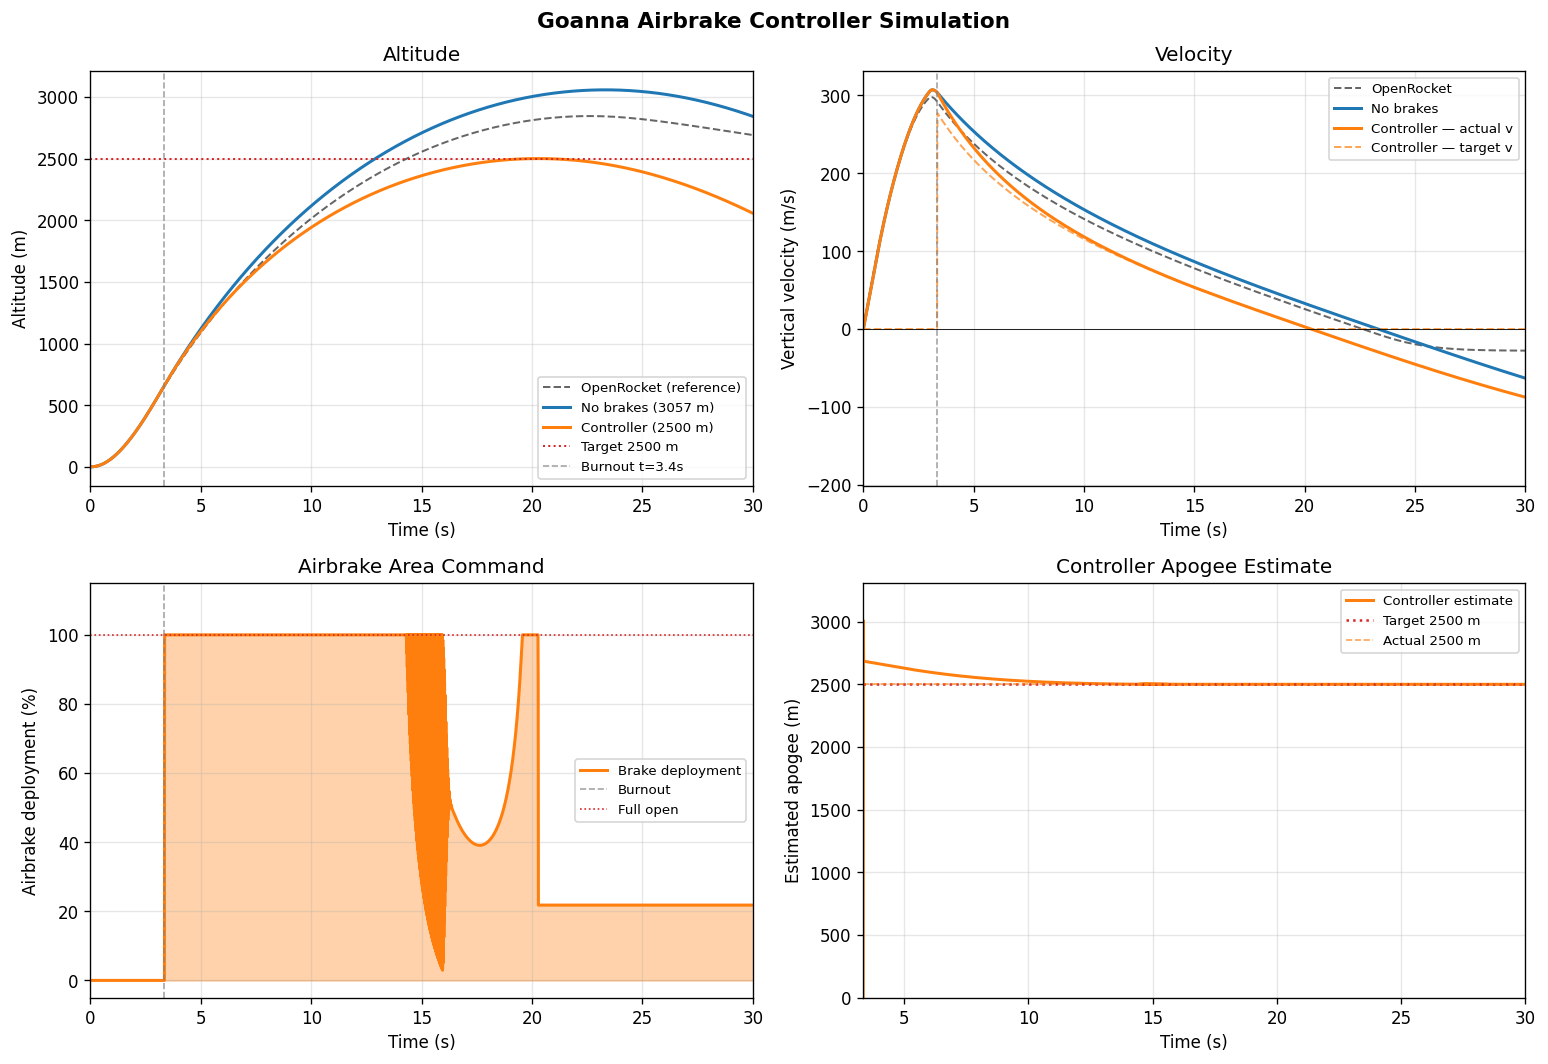

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Goanna Airbrake Controller Simulation", fontsize=13, fontweight='bold')

# ── 1. Altitude vs time ───────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(t_or, h_or, 'k--', lw=1.2, alpha=0.6, label='OpenRocket (reference)')
ax.plot(sim_open['t'], sim_open['h'], 'C0-', lw=1.8, label=f'No brakes ({apogee_open:.0f} m)')
ax.plot(sim_ctrl['t'], sim_ctrl['h'], 'C1-', lw=1.8, label=f'Controller ({apogee_ctrl:.0f} m)')
ax.axhline(TARGET_APOGEE, color='C3', ls=':', lw=1.2, label=f'Target {TARGET_APOGEE:.0f} m')
ax.axvline(t_burnout, color='gray', ls='--', lw=1, alpha=0.7, label=f'Burnout t={t_burnout:.1f}s')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Altitude (m)')
ax.set_title('Altitude')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(t_apogee_ctrl * 1.4, 30))

# ── 2. Velocity vs time ───────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(t_or, v_or, 'k--', lw=1.2, alpha=0.6, label='OpenRocket')
ax.plot(sim_open['t'], sim_open['v'], 'C0-', lw=1.8, label='No brakes')
ax.plot(sim_ctrl['t'], sim_ctrl['v'], 'C1-', lw=1.8, label='Controller — actual v')
ax.plot(sim_ctrl['t'], sim_ctrl['v_target'], 'C1--', lw=1.2, alpha=0.7,
        label='Controller — target v')
ax.axvline(t_burnout, color='gray', ls='--', lw=1, alpha=0.7)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Vertical velocity (m/s)')
ax.set_title('Velocity')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(t_apogee_ctrl * 1.4, 30))

# ── 3. Airbrake area vs time ──────────────────────────────────────────────────
ax = axes[1, 0]
# Convert to % of available travel
travel = A_MAX - A_MIN
brake_pct = (sim_ctrl['A'] - A_MIN) / travel * 100
ax.fill_between(sim_ctrl['t'], 0, brake_pct, alpha=0.35, color='C1')
ax.plot(sim_ctrl['t'], brake_pct, 'C1-', lw=1.8, label='Brake deployment')
ax.axvline(t_burnout, color='gray', ls='--', lw=1, alpha=0.7, label=f'Burnout')
ax.axhline(100, color='C3', ls=':', lw=1, label='Full open')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Airbrake deployment (%)')
ax.set_title('Airbrake Area Command')
ax.set_ylim(-5, 115)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(t_apogee_ctrl * 1.4, 30))

# Print area stats
coast_mask = sim_ctrl['t'] >= t_burnout
max_brake = brake_pct[coast_mask].max() if coast_mask.any() else 0
print(f"Max brake deployment: {max_brake:.1f}% of travel")
print(f"A_min={A_MIN*1e4:.2f} cm², A_max={A_MAX*1e4:.2f} cm², delta={travel*1e4:.2f} cm²")

# ── 4. Estimated apogee vs time ───────────────────────────────────────────────
ax = axes[1, 1]
coast_t   = sim_ctrl['t'][coast_mask]
coast_est = sim_ctrl['apogee_est'][coast_mask]
ax.plot(coast_t, coast_est, 'C1-', lw=1.8, label='Controller estimate')
ax.axhline(TARGET_APOGEE, color='C3', ls=':', lw=1.5, label=f'Target {TARGET_APOGEE:.0f} m')
ax.axhline(apogee_ctrl, color='C1', ls='--', lw=1, alpha=0.7,
           label=f'Actual {apogee_ctrl:.0f} m')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Estimated apogee (m)')
ax.set_title('Controller Apogee Estimate')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
# Clip y-axis to reasonable range
valid = coast_est[np.isfinite(coast_est)]
if len(valid):
    ax.set_ylim(max(valid.min() * 0.9, 0), min(valid.max() * 1.1, 8000))
ax.set_xlim(coast_t[0] if len(coast_t) else 0, max(t_apogee_ctrl * 1.4, 30))

plt.tight_layout()
plt.show()

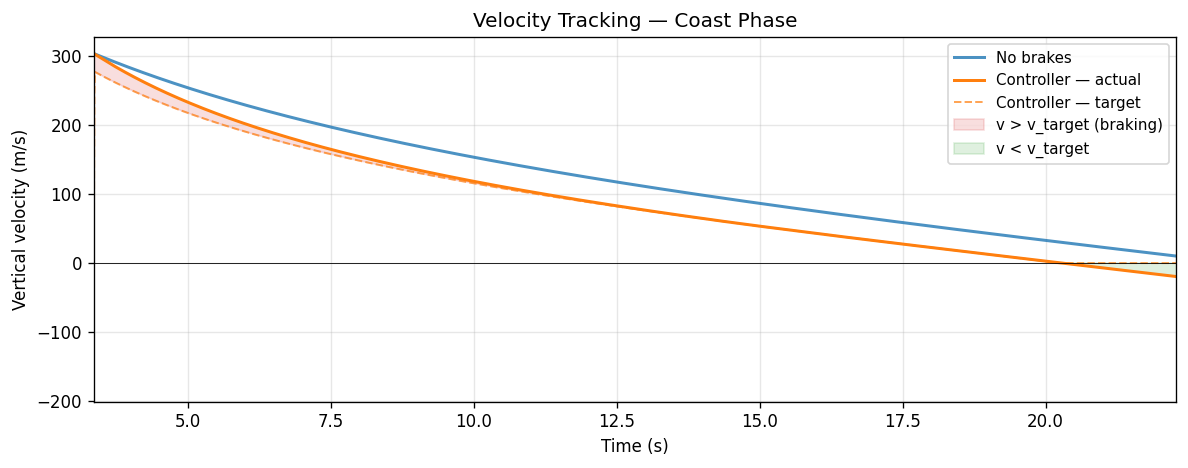

In [8]:
# ── Detailed coast phase: velocity tracking ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

coast_v      = sim_ctrl['v'][coast_mask]
coast_vtgt   = sim_ctrl['v_target'][coast_mask]
coast_v_open = sim_open['v'][sim_open['t'] >= t_burnout]
coast_t_open = sim_open['t'][sim_open['t'] >= t_burnout]

ax.plot(coast_t_open, coast_v_open, 'C0-', lw=1.8, alpha=0.8, label='No brakes')
ax.plot(coast_t, coast_v, 'C1-', lw=1.8, label='Controller — actual')
ax.plot(coast_t, coast_vtgt, 'C1--', lw=1.2, alpha=0.7, label='Controller — target')
ax.fill_between(coast_t, coast_vtgt, coast_v,
                where=(coast_v > coast_vtgt), alpha=0.15, color='C3', label='v > v_target (braking)')
ax.fill_between(coast_t, coast_vtgt, coast_v,
                where=(coast_v < coast_vtgt), alpha=0.15, color='C2', label='v < v_target')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Vertical velocity (m/s)')
ax.set_title('Velocity Tracking — Coast Phase')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(t_burnout, t_apogee_ctrl + 2)
plt.tight_layout()
plt.show()

In [9]:
# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 52)
print(" SIMULATION SUMMARY")
print("=" * 52)
print(f"  OpenRocket apogee (reference): {h_or.max():.1f} m")
print(f"  Python sim, no brakes:         {apogee_open:.1f} m")
print(f"  Python sim, controller:        {apogee_ctrl:.1f} m")
print(f"  Target:                        {TARGET_APOGEE:.1f} m")
print(f"  Error from target:             {apogee_ctrl - TARGET_APOGEE:+.1f} m")
print()
print(f"  Motor burnout: t={t_burnout:.2f}s")
print(f"  Apogee (ctrl): t={t_apogee_ctrl:.1f}s")
print()
# Max brake during coast
A_coast = sim_ctrl['A'][coast_mask]
if len(A_coast):
    pct_max = (A_coast.max() - A_MIN) / (A_MAX - A_MIN) * 100
    pct_mean = (A_coast.mean() - A_MIN) / (A_MAX - A_MIN) * 100
    print(f"  Max brake deployment:  {pct_max:.1f}%")
    print(f"  Mean brake (coast):    {pct_mean:.1f}%")
print("=" * 52)

 SIMULATION SUMMARY
  OpenRocket apogee (reference): 2844.7 m
  Python sim, no brakes:         3057.3 m
  Python sim, controller:        2500.1 m
  Target:                        2500.0 m
  Error from target:             +0.1 m

  Motor burnout: t=3.35s
  Apogee (ctrl): t=20.3s

  Max brake deployment:  100.0%
  Mean brake (coast):    40.9%
